In [31]:
import warnings
warnings.filterwarnings('ignore')

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
# Parameters.
learning_rate = 0.01
training_steps = 1000
display_step = 50

In [34]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [35]:
# Xây dựng dữ liệu
X = np.array([3.3,4.4,5.5,6.71,6.93,4.168,9.779,6.182,7.59,2.167,
              7.042,10.791,5.313,7.997,5.654,9.27,3.1])
Y = np.array([1.7,2.76,2.09,3.19,1.694,1.573,3.366,2.596,2.53,1.221,
              2.827,3.465,1.65,2.904,2.42,2.94,1.3])

In [36]:
X_tensor = torch.from_numpy(X).float()
Y_tensor = torch.from_numpy(Y).float()

In [37]:
inputs = torch.from_numpy(X)
targets = torch.from_numpy(Y)

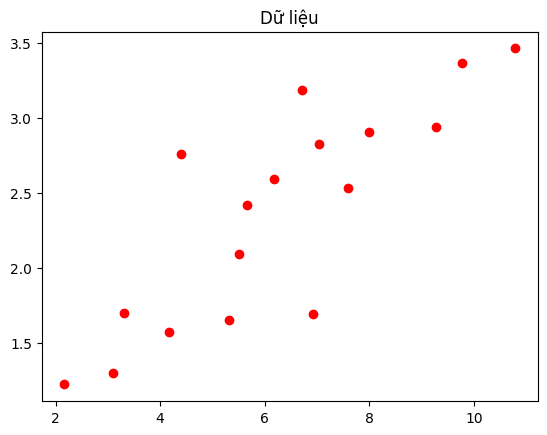

In [38]:
# Trực quan hóa dữ liệu
plt.plot(X, Y,'ro',marker = 'o')
plt.title('Dữ liệu')
plt.show()

In [39]:
def model(x):
    return x * w + b


In [40]:
w = torch.randn(1, requires_grad = True)
b = torch.randn(1, requires_grad = True)

In [41]:
# Xây dựng hàm mất mát (loss function)
# Đọc thêm về reduce_mean tại: https://docs.w3cub.com/tensorflow~python/tf/reduce_mean

# MSE loss
def mse(t1, t2):
    diff = t1 - t2
    return torch.sum(diff**2) / diff.numel()

In [42]:
losses = []
for i in range(training_steps):
    preds = model(x=X_tensor)
    loss = mse(preds,Y_tensor)
    losses.append(loss)
    loss.backward()
    with torch.no_grad():
        w -= w.grad * learning_rate
        b -= b - b.grad * learning_rate
        w.grad.zero_()
        b.grad.zero_()

In [ ]:
clean_losses = [i.item() for i in losses]

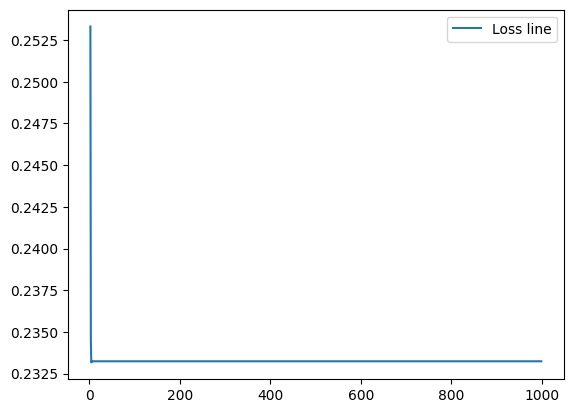

In [63]:
# Biểu đồ biểu diễn độ biến thiên của hàm mất mát qua các vòng lặp
plt.plot([i for i in range(2,len(clean_losses))], clean_losses[2:], label='Loss line')
# plt.plot(X, np.array(W * X + b), label='Fitted line')
plt.legend()
plt.show()

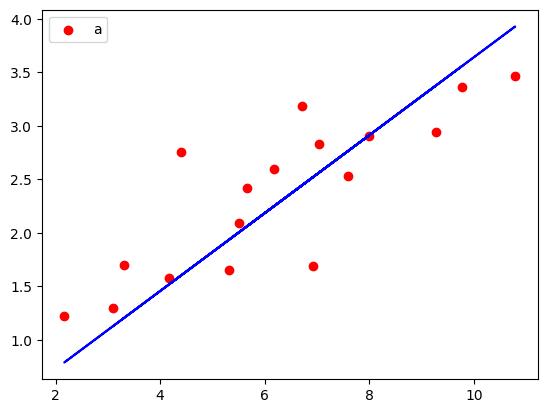

In [ ]:
w = w.detach().numpy()
b = b.detach().numpy()
plt.figure()
plt.scatter(X, Y,color = 'red',marker = 'o', label = 'Dữ liệu gốc')
plt.plot(X, w * X + b, color = 'blue', label = 'Fitted line')
plt.legend()
plt.show()
plt.show()